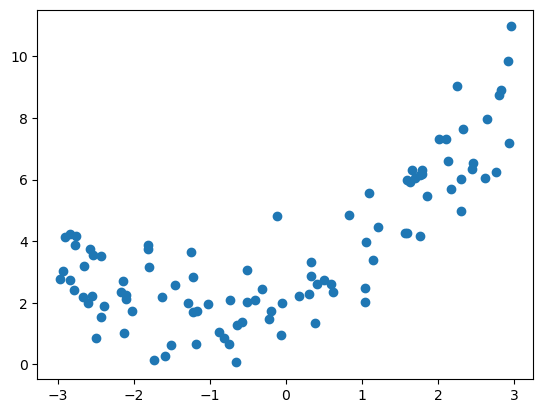

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
plt.figure()
plt.scatter(X,y)
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ( train_test_split)
model = LinearRegression()

In [3]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


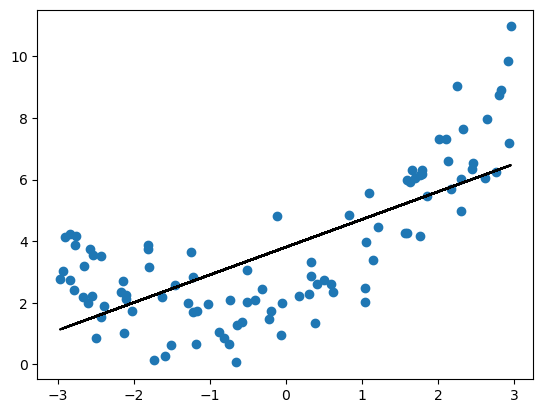

In [4]:
pred = model.intercept_ + model.coef_*X
plt.figure()
plt.scatter(X,y)
plt.plot (X, pred,'k-')

plt.show()

In [5]:
model.score(X,y)

0.5109752328701319

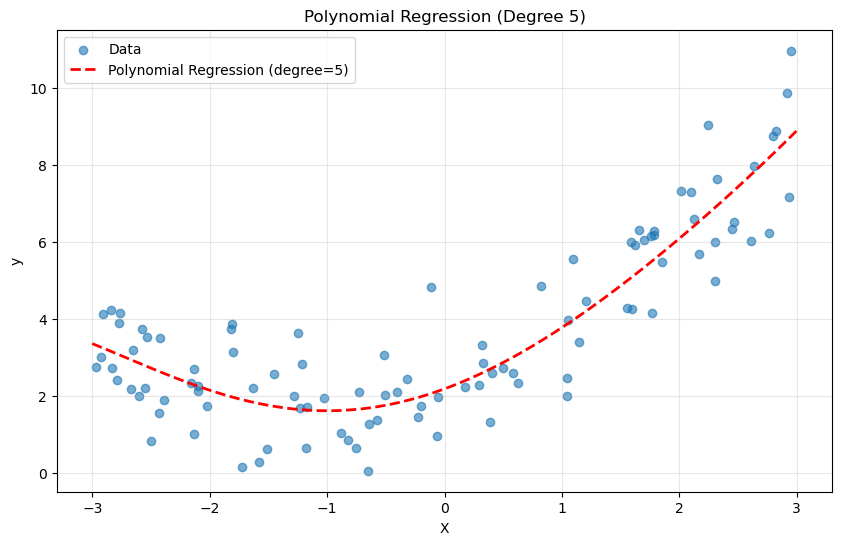

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


pol = PolynomialFeatures(degree=5, include_bias=False)
X_p = pol.fit_transform(X)  

model = LinearRegression()
model.fit(X_p, y)

X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
X_line_p = pol.transform(X_line)  
y_line = model.predict(X_line_p)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_line, y_line, 'r--', linewidth=2, label='Polynomial Regression (degree=5)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression (Degree 5)')
plt.grid(True, alpha=0.3)
plt.show()


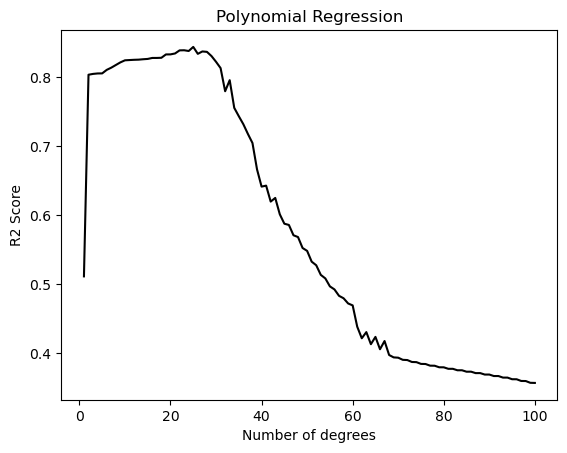

In [7]:
model = LinearRegression()
scores = []
for i in range ( 1,101 ) : 
    polynomial = PolynomialFeatures( degree = i , include_bias = False ) 
    X_p = polynomial.fit_transform(X) 
    model.fit(X_p,y) 
    score = model.score( X_p ,y )
    scores.append(score)

plt.figure() 
plt.plot( range(1,101), scores , color = 'black' , marker = None ) 
plt.xlabel ( 'Number of degrees')
plt.ylabel ( 'R2 Score')
plt.title('Polynomial Regression')
plt.show()


Having multiple degrees is overfitting and might lead to distortion

with high variance leads to low bias

To get how complex the model should be we use the learning curves 

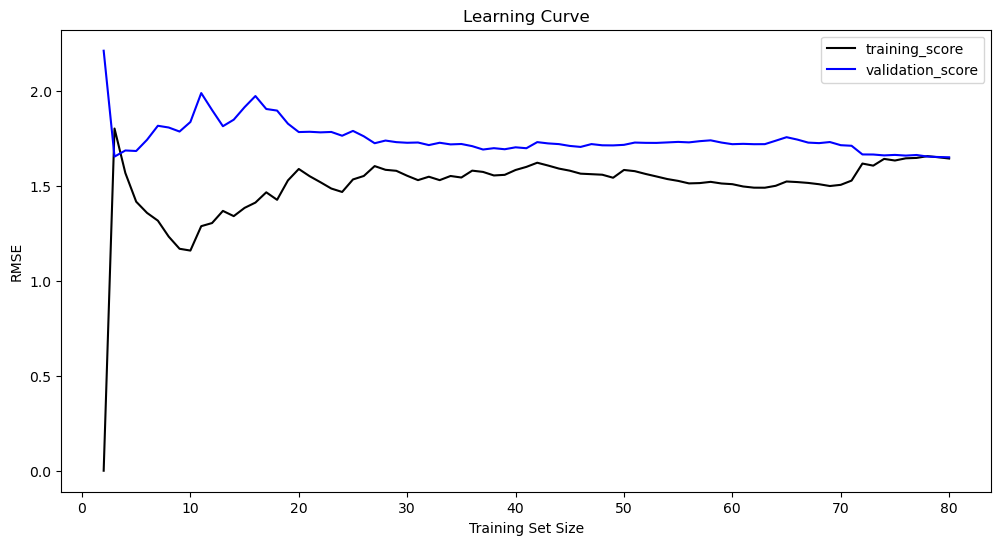

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def learning(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
    t_scores, v_scores = [], []

    for i in range(2, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = (12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Both training error and test error is high which means underfitting ,Adding more instances wont solve the problem instead a complex model

 Both the training curve (black) and validation curve (blue) flatten out very early (around a training size of 10) and stay completely flat all the way to 80 samples. Adding more data does not help the model learn anything new.

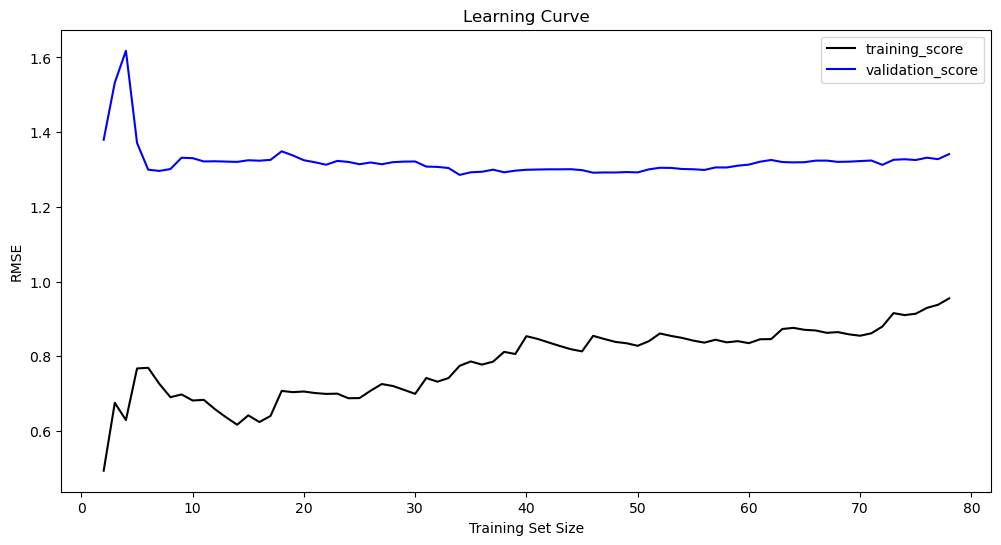

In [9]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 2, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state = 24)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


The error rate is low in both including the gaps the reason why it is good because as with  more instances the model learns new patterns unlike in the linear regression where it fails to learn anything

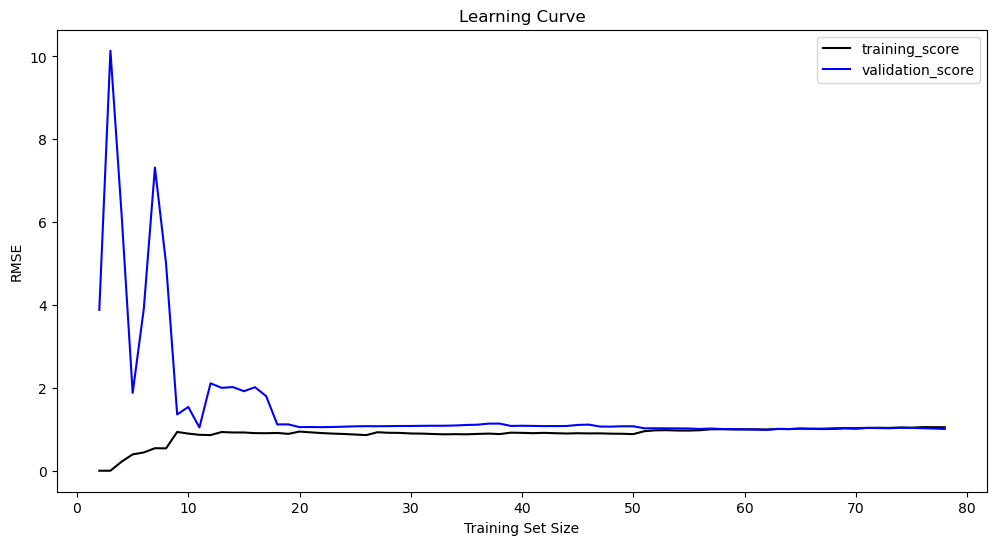

In [10]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 4, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = LinearRegression()
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Here the model is overfitting 

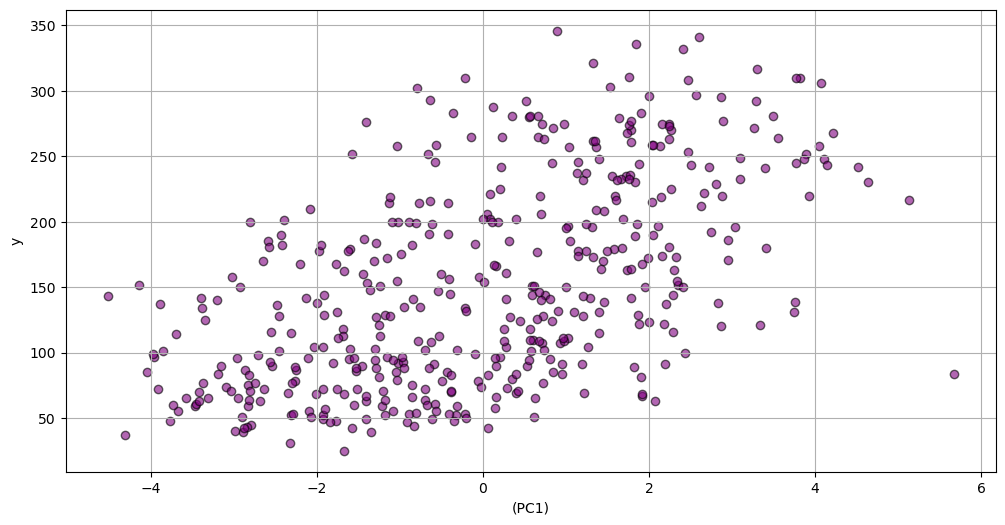

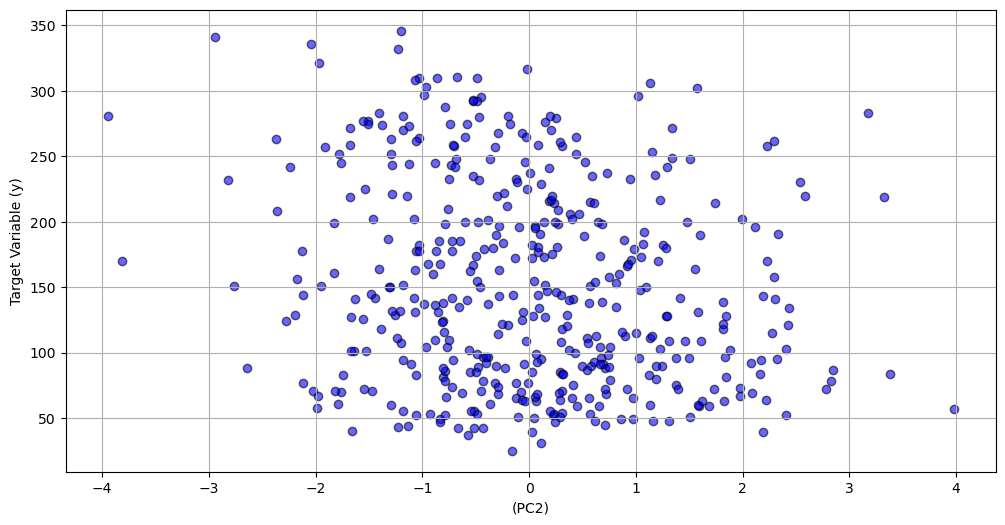

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame 
X = df.drop('target', axis=1) 
y = df['target']


pca_pipeline = make_pipeline(StandardScaler(), PCA(n_components=2))
X_pca = pca_pipeline.fit_transform(X)


pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]


plt.figure(figsize=(12, 6))
plt.scatter(pc1, y, color='purple', alpha=0.6, edgecolors='k')
plt.xlabel('(PC1)')
plt.ylabel('y')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(pc2, y, color='blue', alpha=0.6, edgecolors='k')
plt.xlabel('(PC2)')
plt.ylabel('Target Variable (y)')
plt.grid(True)
plt.show()


The diabetic dataset is straight linear and linear regression works well here

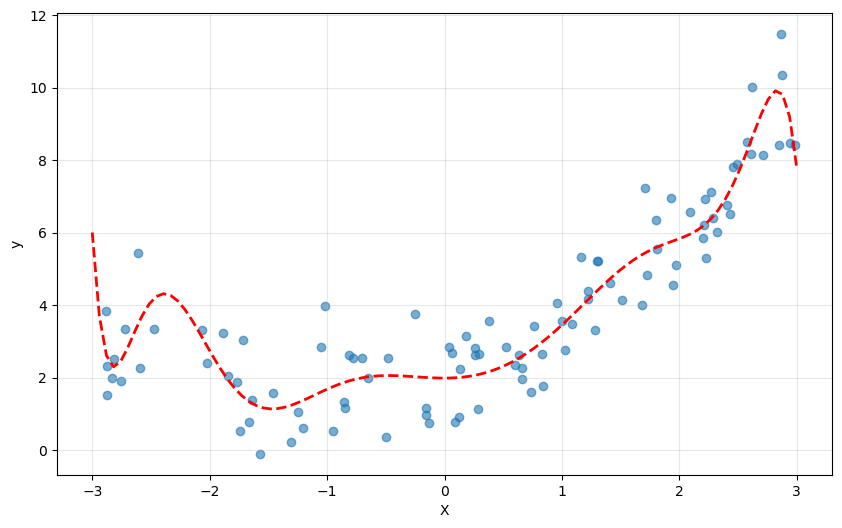

In [12]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)


pol = PolynomialFeatures(degree=12, include_bias=False)
X_p = pol.fit_transform(X)  

model = LinearRegression()
model.fit(X_p, y)

X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
X_line_p = pol.transform(X_line)  
y_line = model.predict(X_line_p)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_line, y_line, 'r--', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
np.round(model.coef_,2)

array([[ 0.01,  0.9 ,  1.01, -0.45, -0.03,  0.15, -0.13, -0.01,  0.03,
        -0.  , -0.  ,  0.  ]])

Now we add a ridge regression that shrinks the weights towards zero but not zero ,Handles correlated features by spreading the weight evenly.

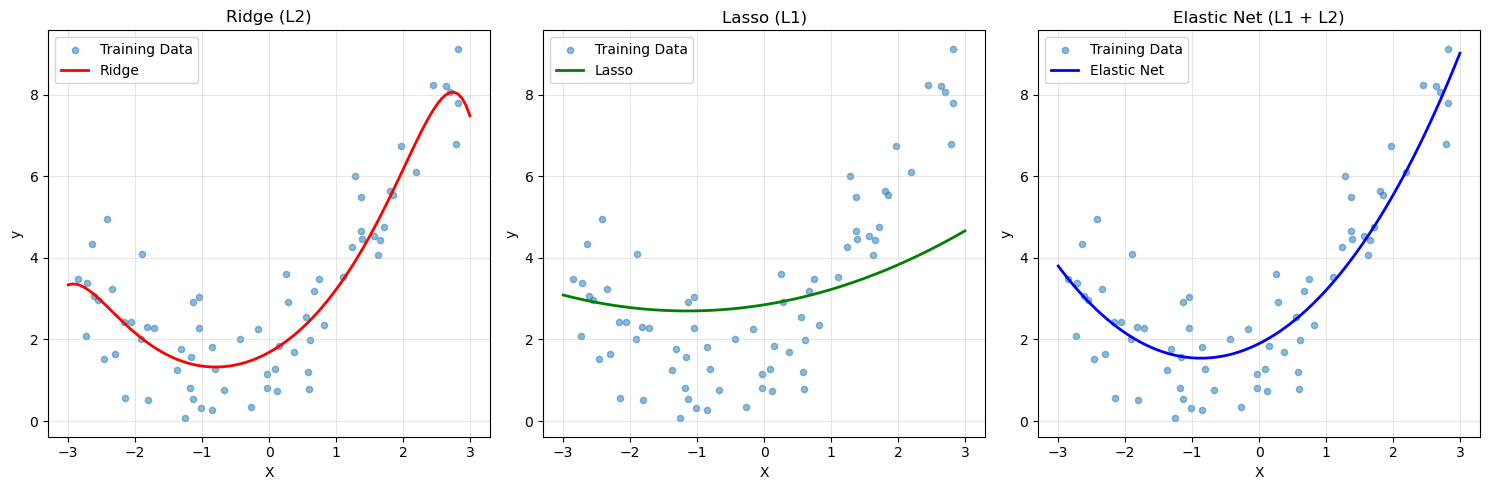

COEFFICIENTS (Degree 10 Polynomial)
Term       Ridge        Lasso        Elastic Net 
------------------------------------------------------------
X^1      1.5082       0.4366       1.3710      
X^2      1.5161       0.2937       1.2282      
X^3      0.3131       0.0000       0.0489      
X^4      0.2489       0.0000       0.0545      
X^5      -0.0412      0.0000       0.0000      
X^6      -0.0411      0.0000       0.0000      
X^7      -0.1205      0.0000       0.0000      
X^8      -0.1462      0.0000       0.0000      
X^9      -0.1497      0.0000       -0.0000     
X^10     -0.2297      0.0000       -0.0000     

Non-zero coefficients:
  Ridge: 10
  Lasso: 2
  Elastic Net: 4


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)

lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
lasso_pipeline.fit(X_train, y_train)

elastic_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])
elastic_pipeline.fit(X_train, y_train)


X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
y_ridge = ridge_pipeline.predict(X_line)
y_lasso = lasso_pipeline.predict(X_line)
y_elastic = elastic_pipeline.predict(X_line)


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_ridge, 'r-', linewidth=2, label='Ridge')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Ridge (L2)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_lasso, 'g-', linewidth=2, label='Lasso')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Lasso (L1)')
plt.grid(True, alpha=0.3)


plt.subplot(1, 3, 3)
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training Data')
plt.plot(X_line, y_elastic, 'b-', linewidth=2, label='Elastic Net')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Elastic Net (L1 + L2)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ridge_coefs = ridge_pipeline.named_steps['ridge'].coef_.flatten()
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_.flatten()
elastic_coefs = elastic_pipeline.named_steps['elastic'].coef_.flatten()

print("="*60)
print("COEFFICIENTS (Degree 10 Polynomial)")
print("="*60)
print(f"{'Term':<10} {'Ridge':<12} {'Lasso':<12} {'Elastic Net':<12}")
print("-"*60)
for i in range(10):
    print(f"X^{i+1:<6} {ridge_coefs[i]:<12.4f} {lasso_coefs[i]:<12.4f} {elastic_coefs[i]:<12.4f}")

print(f"\nNon-zero coefficients:")
print(f"  Ridge: {np.sum(np.abs(ridge_coefs) > 1e-6)}")
print(f"  Lasso: {np.sum(np.abs(lasso_coefs) > 1e-6)}")
print(f"  Elastic Net: {np.sum(np.abs(elastic_coefs) > 1e-6)}")

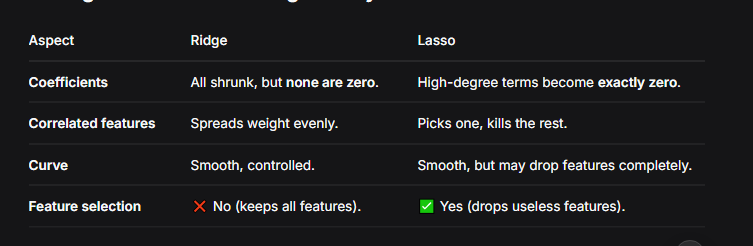

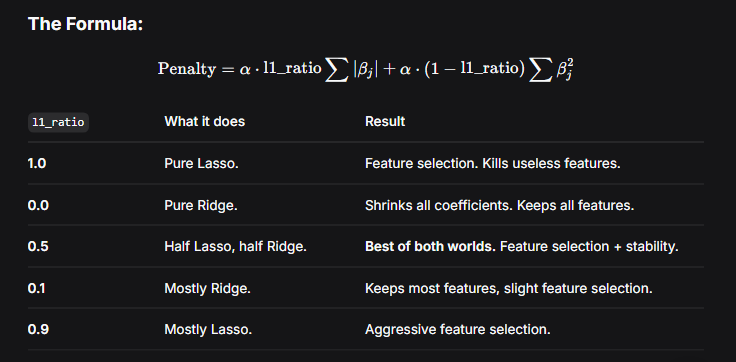

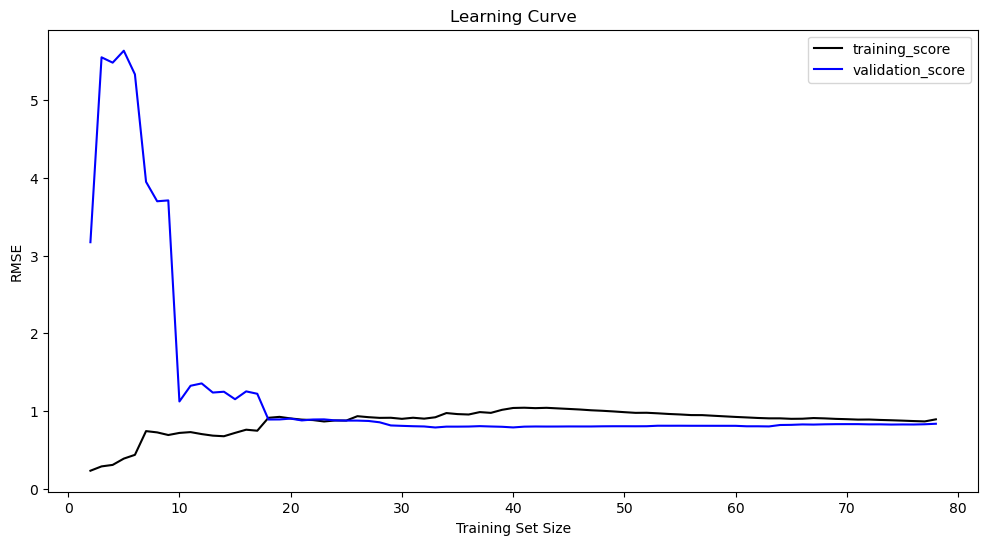

In [15]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 3, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = Ridge(2)
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


Ridge added penalty for coeffecients to be very bigger and made them smaller now the model is good fit

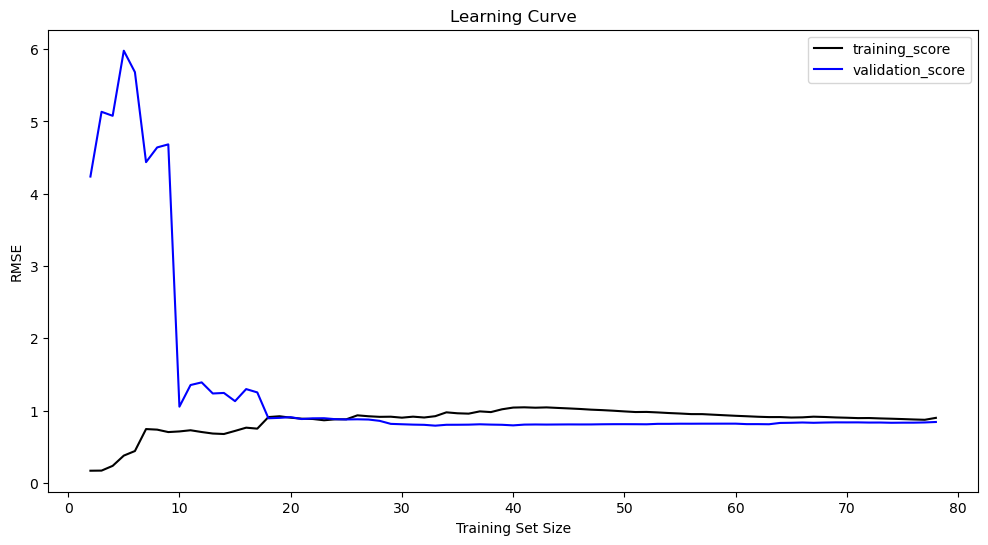

In [16]:

def learning(model, X, y):
    poly = PolynomialFeatures( degree = 3, include_bias=False ) 
    X = poly.fit_transform(X) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
    t_scores, v_scores = [], []

    for i in range(4, len(X_train) + 1): 
        model.fit(X_train[:i], y_train[:i])
        
        t_score = root_mean_squared_error(y_train[:i], model.predict(X_train[:i]))
        v_score = root_mean_squared_error(y_test, model.predict(X_test)) 
        t_scores.append(t_score)
        v_scores.append(v_score)
        
    return t_scores, v_scores


model = Lasso(0.05)
t, v = learning(model, X, y)


x_axis = range(2, len(t) + 2)

plt.figure(figsize = ( 12,6))
plt.title('Learning Curve')
plt.plot(x_axis, t, color='black', label='training_score')
plt.plot(x_axis, v, color='blue', label='validation_score')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.legend()
plt.show()


In [17]:
import pandas as pd

df = pd.read_csv("C:/Users/hp/Downloads/auto-mpg.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [18]:
df.shape

(398, 9)

The Problem: Predict a car's fuel efficiency (mpg) based on its engine size, weight, horsepower, etc.

In [19]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [20]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


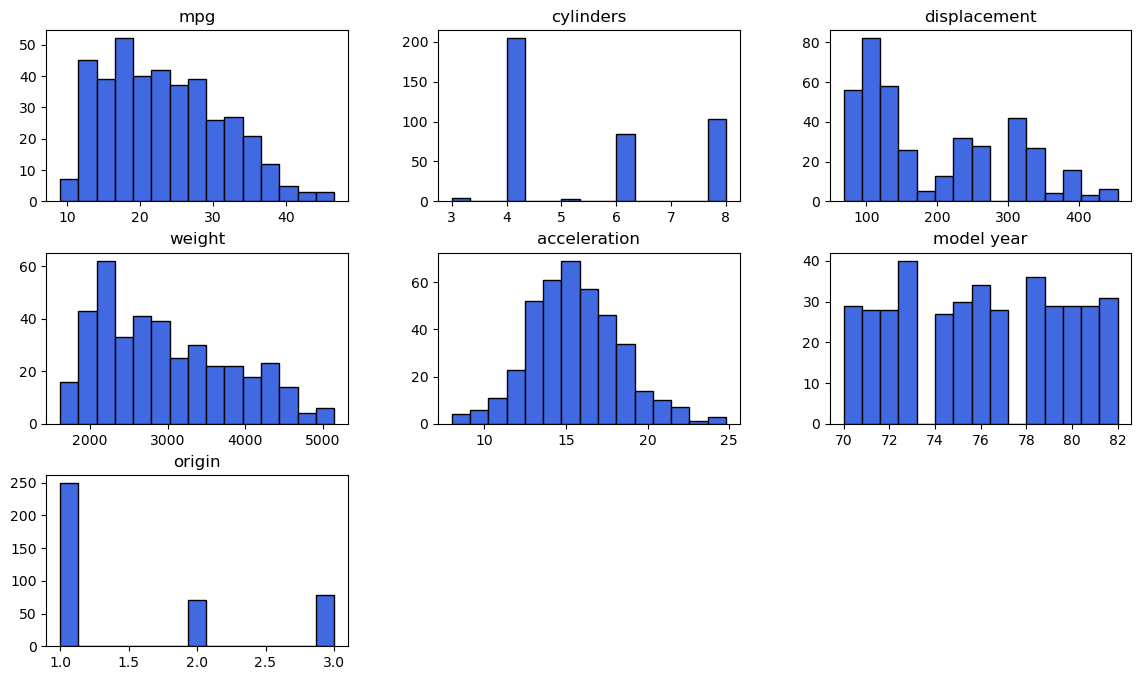

In [21]:
df.hist( grid = False , color = 'royalblue' , edgecolor = 'black' , figsize = (14,8) , bins = 15) 
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [23]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [24]:
df['horsepower']  = df['horsepower'].replace('?' , np.nan)
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


In [25]:
df = df.dropna( subset = 'horsepower' , how = 'any' ) 
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


In [26]:
df['horsepower'] =df['horsepower'].astype( 'float32' )

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float32
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float32(1), float64(3), int64(4), object(1)
memory usage: 29.1+ KB


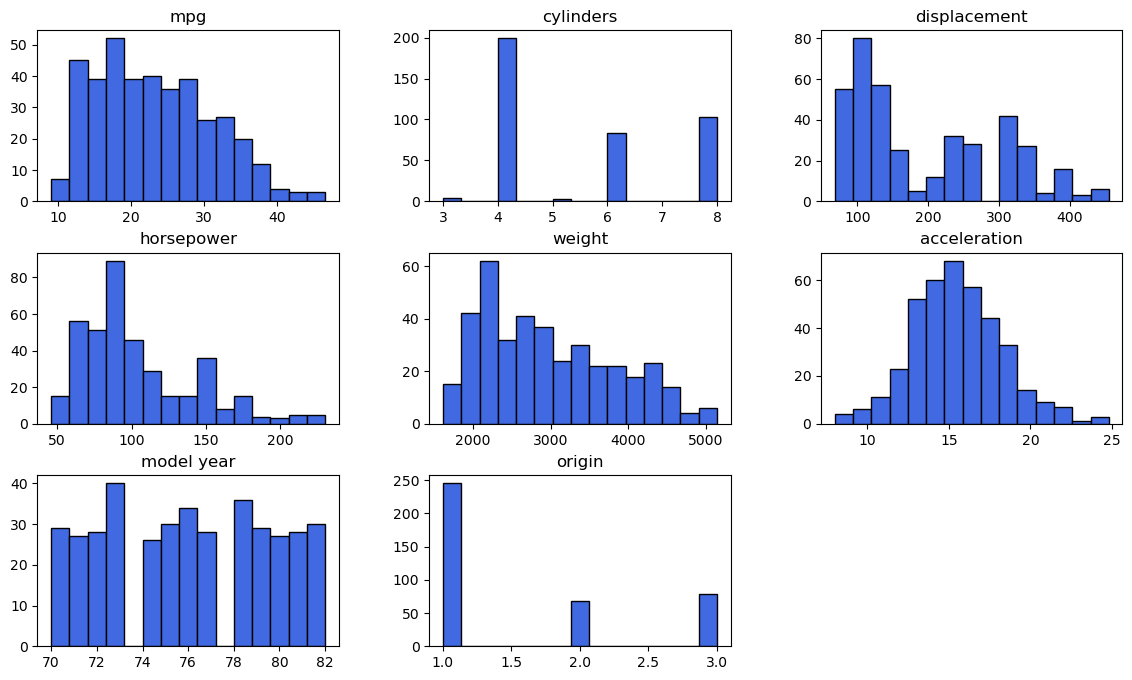

In [28]:
df.hist( grid = False , color = 'royalblue' , edgecolor = 'black' , figsize = (14,8) , bins = 15) 
plt.show()

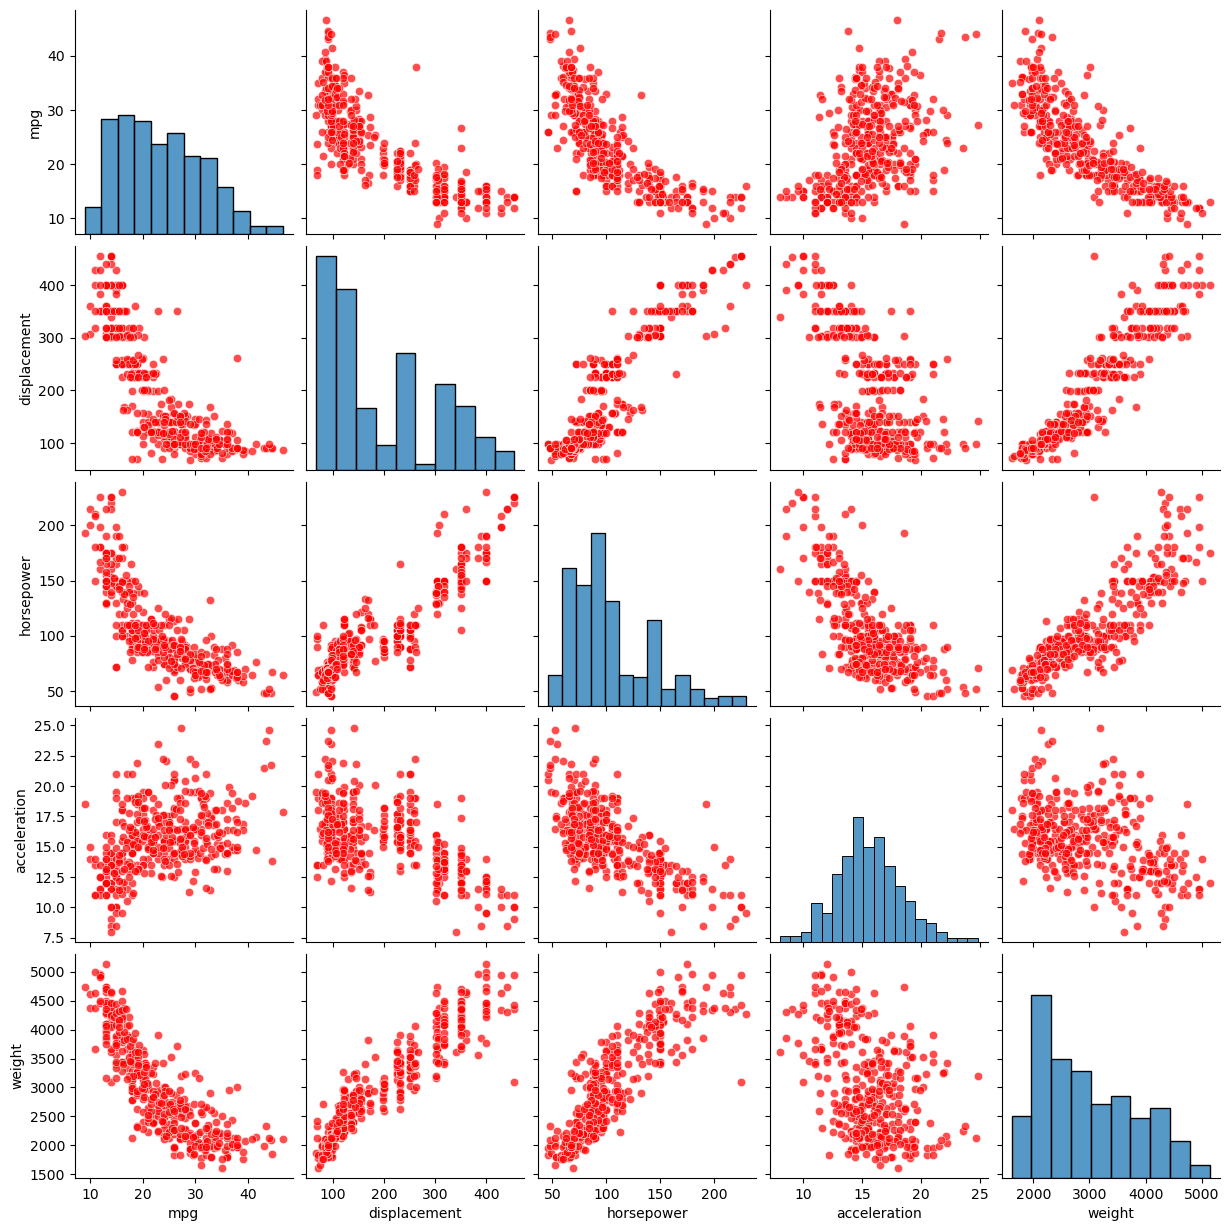

In [29]:
import seaborn as sns
sns.pairplot ( df[ ['mpg' ,'displacement' ,'horsepower' , 'acceleration' ,'weight'] ] ,plot_kws = {'color' : 'red' , 'alpha' : 0.7} )
plt.show()

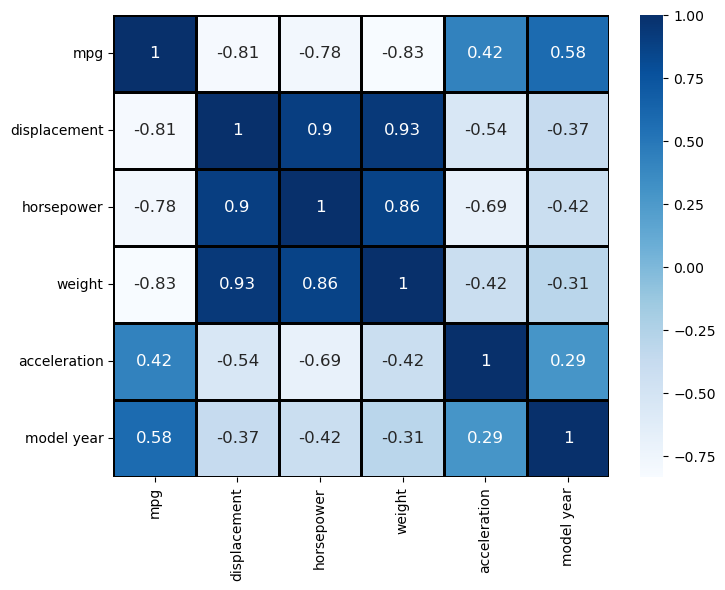

In [30]:
columns = ['mpg', 'displacement' , 'horsepower' , 'weight' ,'acceleration', 'model year' ]
corr = df[ columns ].corr()
plt.figure( figsize = (8,6 )) 
sns.heatmap ( corr , cmap = 'Blues' , annot = True, linecolor='black' , annot_kws= {'size' : 12 } ,linewidths=1 )
plt.show()

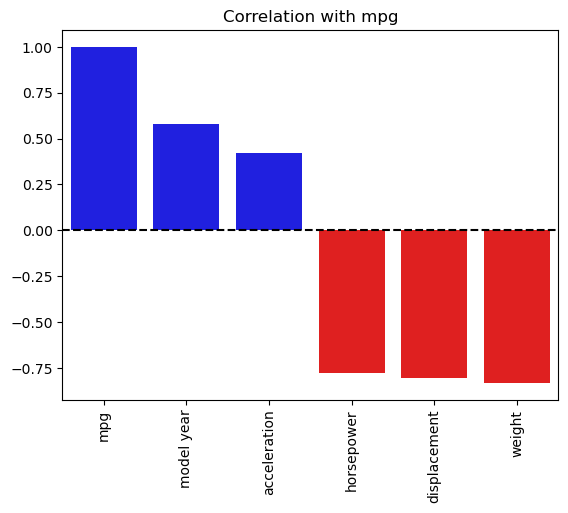

In [31]:
corr_df = corr['mpg'].sort_values(ascending= False ) 
color = [ 'red' if x < 0 else 'blue' for x in corr_df ]
sns.barplot( x = corr_df.index, y= corr_df.values , palette = color , legend = False ,hue = corr_df.index )
plt.title('Correlation with mpg')
plt.xlabel('')
plt.axhline(0 ,color = 'black' , linestyle = 'dashed')
plt.xticks(rotation = 90 )
plt.show()

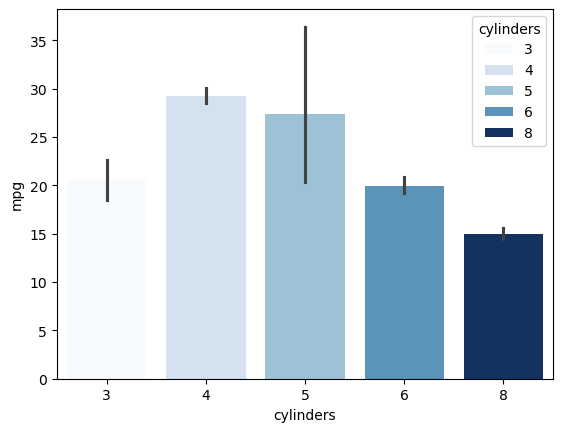

In [32]:
plt.figure()
sns.barplot ( df , y ='mpg', x = 'cylinders' , hue = 'cylinders', palette = 'Blues')
plt.show()

In [33]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [34]:
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression ,Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , learning_curve
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


X = df.drop(columns=['mpg', 'car name'])
y = df['mpg']

X['cylinders'] = X['cylinders'].astype(str)

numeric_cols = ['displacement', 'horsepower', 'weight', 'acceleration', 'model year']
ordinal_cols = ['cylinders']
nominal_cols = ['origin']


preprocess = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_cols),
    ('ordinal', OrdinalEncoder(categories=[['3', '4', '5', '6', '8']]), ordinal_cols),
    ('nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols)
])

lin_reg = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])



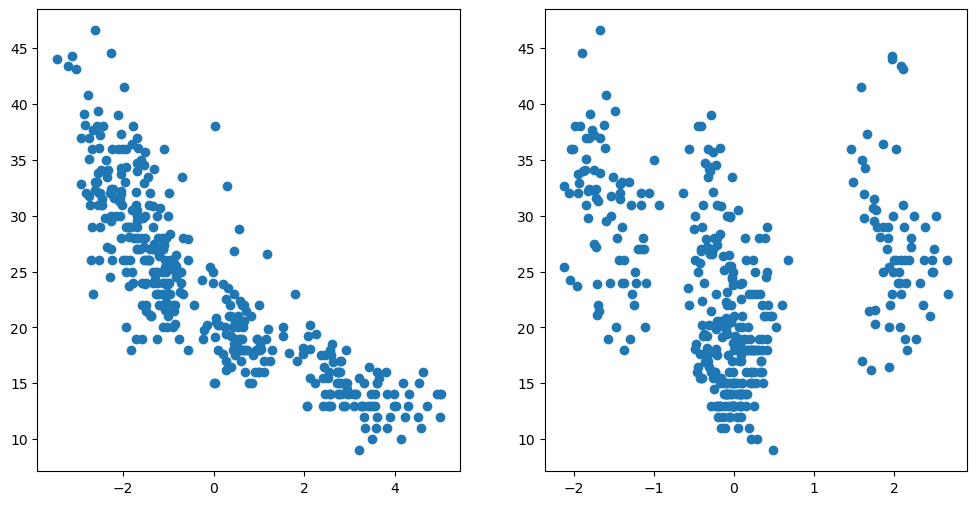

In [35]:
# Applying pca pipeline to check linearity 

pca_ = Pipeline ( [ 
    ('preprocess' , preprocess) , 
    ('scaling' , StandardScaler() ) , 
    ('pca', PCA( n_components=2)) ]
                ) 

V = pca_.fit_transform(X) 

fig , ax = plt.subplots( 1,2, figsize = (12,6))
ax[0].scatter( V[:,0] , y )
ax[1].scatter(V[:,1],y)
plt.show()

In [36]:
pca_.named_steps['pca'].explained_variance_ratio_

array([0.564319  , 0.16114707])

Negative relation might be slightly polynomial

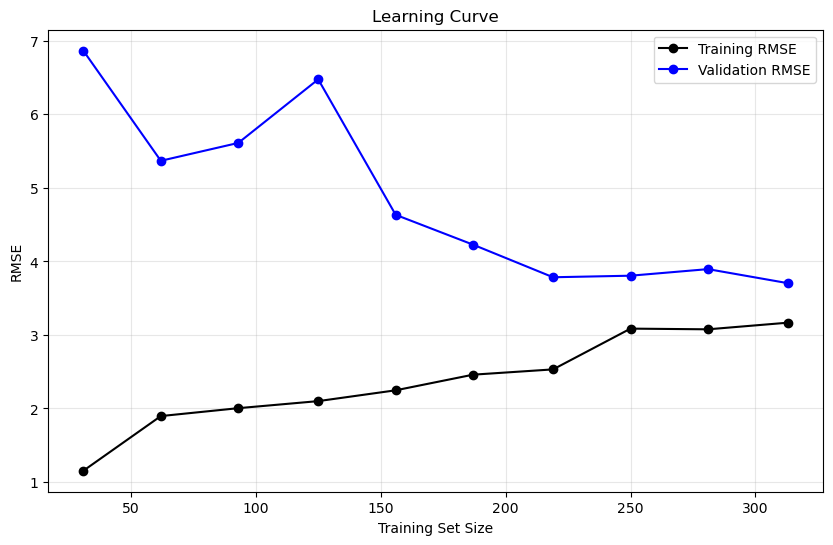

In [37]:

train_sizes, train_scores, test_scores = learning_curve(
    estimator=lin_reg,
    X=X,
    y=y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = np.sqrt(-train_scores)
test_rmse = np.sqrt(-test_scores)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Training RMSE', color='black')
plt.plot(train_sizes, test_rmse.mean(axis=1), 'o-', label='Validation RMSE', color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
train_sizes

array([ 31,  62,  93, 125, 156, 187, 219, 250, 281, 313])

In [39]:
test_scores[0]

array([-76.32059296, -26.78715894, -37.4987901 , -48.15467614,
       -54.05367325])

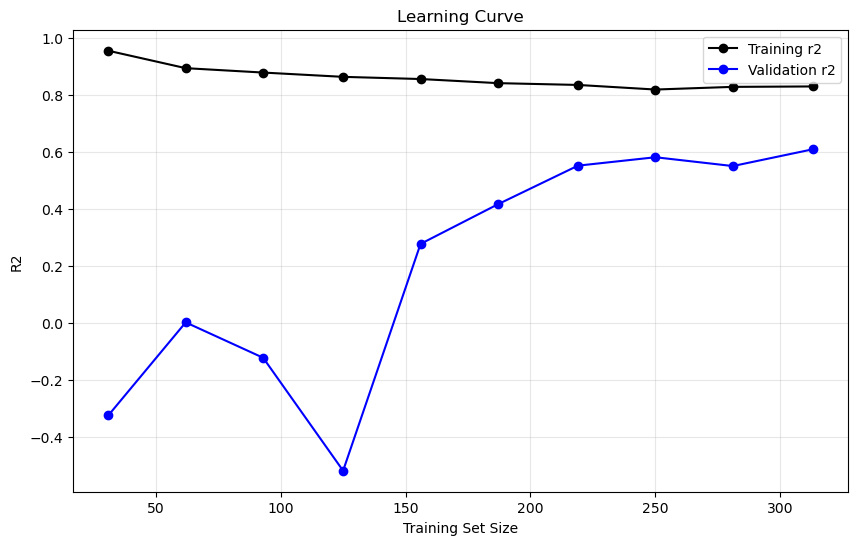

In [40]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=lin_reg,
    X=X,
    y=y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)


plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training r2', color='black')
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='Validation r2', color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('R2')
plt.title('Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Because in the dataset correlation there was many correlated features which adds the overfitting in the training set 

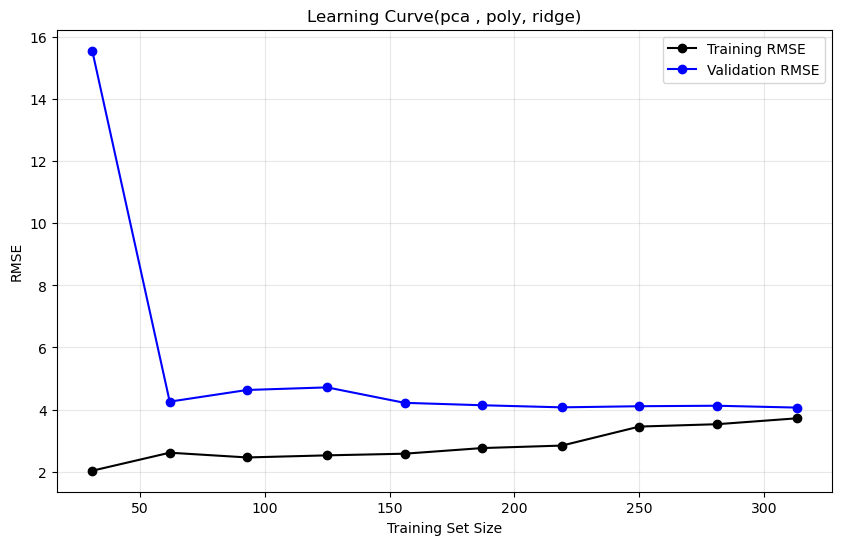

In [41]:
pol_reg = Pipeline([
    ('preprocess', preprocess),
    ('pca', PCA(n_components=1)),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
    ('model', Ridge(alpha = 5))
])

train_sizes, train_scores, test_scores = learning_curve(
    estimator=pol_reg,
    X=X,
    y=y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = np.sqrt(-train_scores)
test_rmse = np.sqrt(-test_scores)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Training RMSE', color='black')
plt.plot(train_sizes, test_rmse.mean(axis=1), 'o-', label='Validation RMSE', color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve(pca , poly, ridge)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

param_grid = [ 
    { 'model' : [LinearRegression() ] } , 
    {'model' : [Lasso() ] ,
     'model__alpha' : [ 0.5,1,5,10,15] },
    {'model' : [Ridge() ] ,
     'model__alpha' :[ 0.5,1,5,10,15] 
    }
]
X_train, X_test, y_train, y_test = train_test_split ( X, y , test_size = 0.2 , shuffle = True ,random_state = 26) 
grid_search = GridSearchCV(pipeline ,param_grid= param_grid , scoring ='neg_root_mean_squared_error' ,cv = 5)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"[{'model': [LinearRegression()]}, {'model': [Lasso()], 'model__alpha': [0.5, 1, ...]}, ...]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('ordinal', ...), ...]"


In [43]:
grid_search.best_params_

{'model': Ridge(), 'model__alpha': 1}

In [44]:
-grid_search.best_score_

np.float64(3.2980366665983647)

In [45]:
cv = grid_search.cv_results_
pd.DataFrame(cv).sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,0.014775,0.001136,0.008108,0.000738,Ridge(),1.0,"{'model': Ridge(), 'model__alpha': 1}",-4.082347,-2.945488,-2.781696,-3.364905,-3.315748,-3.298037,0.449628,1
6,0.014901,0.001331,0.008165,0.000846,Ridge(),0.5,"{'model': Ridge(), 'model__alpha': 0.5}",-4.065697,-2.947821,-2.784153,-3.400972,-3.304604,-3.300649,0.444215,2
0,0.020437,0.007291,0.010520,0.002773,LinearRegression(),NaN,{'model': LinearRegression()},-4.048403,-2.951784,-2.787783,-3.444439,-3.294019,-3.305286,0.439201,3
8,0.014804,0.001431,0.008925,0.001439,Ridge(),5.0,"{'model': Ridge(), 'model__alpha': 5}",-4.191448,-2.955050,-2.783619,-3.221905,-3.402975,-3.310999,0.489166,4
9,0.014873,0.001590,0.007809,0.000242,Ridge(),10.0,"{'model': Ridge(), 'model__alpha': 10}",-4.283067,-2.985207,-2.801940,-3.176628,-3.486445,-3.346657,0.520130,5
10,0.016070,0.002526,0.008659,0.001341,Ridge(),15.0,"{'model': Ridge(), 'model__alpha': 15}",-4.346592,-3.014296,-2.820627,-3.165977,-3.547143,-3.378927,0.539384,6
1,0.014649,0.001046,0.007959,0.000333,Lasso(),0.5,"{'model': Lasso(), 'model__alpha': 0.5}",-4.548369,-3.129529,-2.793979,-3.031670,-3.685181,-3.437746,0.627541,7
2,0.013833,0.000348,0.007708,0.000245,Lasso(),1.0,"{'model': Lasso(), 'model__alpha': 1}",-4.841170,-3.370110,-2.825802,-2.970073,-3.956613,-3.592754,0.737083,8
3,0.014439,0.000370,0.007883,0.000622,Lasso(),5.0,"{'model': Lasso(), 'model__alpha': 5}",-6.902432,-6.121545,-5.411559,-6.143186,-6.511854,-6.218115,0.493972,9
4,0.014908,0.001521,0.008244,0.000385,Lasso(),10.0,"{'model': Lasso(), 'model__alpha': 10}",-8.170207,-7.732417,-7.191747,-7.865019,-8.010439,-7.793966,0.334641,10


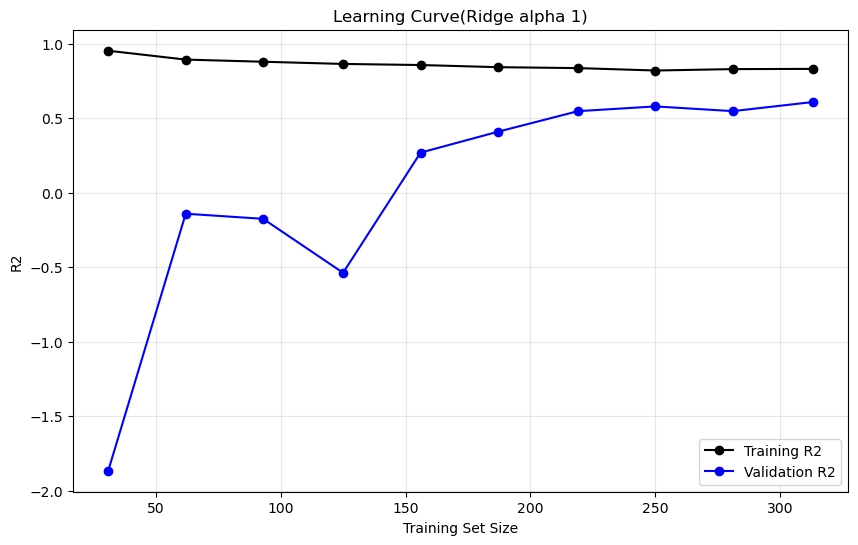

In [46]:
my_model = grid_search.best_estimator_
train_sizes, train_scores, test_scores = learning_curve(
    estimator=my_model,
    X=X,
    y=y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)


plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R2', color='black')
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='Validation R2', color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('R2')
plt.title('Learning Curve(Ridge alpha 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
y_pred = my_model.predict(X_test) 
r2_score(y_test, y_pred)

0.8110702650484218

In [48]:
r2_score(y_train , my_model.predict(X_train))

0.8328372433626702

In [49]:
np.sqrt( mean_squared_error( y_test, y_pred)) , np.sqrt( mean_squared_error( y_train, my_model.predict( X_train)))

(np.float64(3.519141534975022), np.float64(3.1547237974543085))

In [50]:
df['mpg prediction'] = my_model.predict( X)
df.sample(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,mpg prediction
293,31.9,4,89.0,71.0,1925,14.0,79,2,vw rabbit custom,32.891493
198,33.0,4,91.0,53.0,1795,17.4,76,3,honda civic,32.748744
386,25.0,6,181.0,110.0,2945,16.4,82,1,buick century limited,25.616345
357,32.9,4,119.0,100.0,2615,14.8,81,3,datsun 200sx,30.691014
368,27.0,4,112.0,88.0,2640,18.6,82,1,chevrolet cavalier wagon,29.039294
131,32.0,4,71.0,65.0,1836,21.0,74,3,toyota corolla 1200,30.320438
156,16.0,8,400.0,170.0,4668,11.5,75,1,pontiac catalina,12.848638
313,28.0,4,151.0,90.0,2678,16.5,80,1,chevrolet citation,28.294843
363,22.4,6,231.0,110.0,3415,15.8,81,1,buick century,23.416439
262,19.2,8,305.0,145.0,3425,13.2,78,1,chevrolet monte carlo landau,20.809771


In [51]:
coef = my_model.named_steps['model'].coef_
features= my_model.named_steps['preprocess'].get_feature_names_out()
coef_ser = pd.Series( coef, index = features).sort_values( ascending= False ) 
coef_ser

numeric__displacement    3.236031
numeric__model year      2.830203
nominal__origin_3        2.672941
nominal__origin_2        2.223582
numeric__acceleration    0.232989
numeric__horsepower     -1.039517
ordinal__cylinders      -1.440522
numeric__weight         -5.177348
dtype: float64

In [52]:
df.groupby( by = ['origin' , 'cylinders']  )[['mpg' , 'horsepower']].mean()

mpg  horsepower
origin cylinders                       
1      4          28.013043   80.956520
       6          19.645205   99.671234
       8          14.963107  158.300964
2      4          28.106557   78.311478
       5          27.366667   82.333336
       6          20.100000  113.500000
3      3          20.550000   99.250000
       4          31.595652   75.579712
       6          23.883333  115.833336

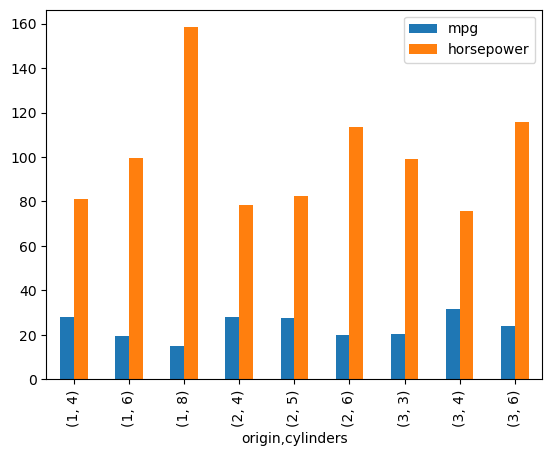

In [53]:
df.groupby( by = ['origin' , 'cylinders']  )[['mpg' , 'horsepower']].mean().plot( kind='bar')
plt.show()

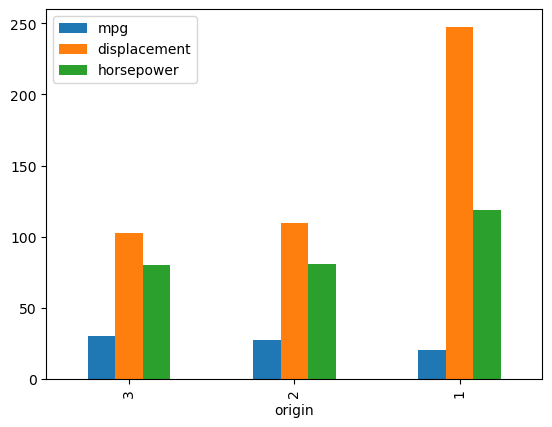

In [54]:
df.groupby( by = ['origin']  )[['mpg', 'displacement' , 'horsepower']].mean().sort_values(by ='mpg', ascending = False).plot( kind = 'bar')
plt.show()

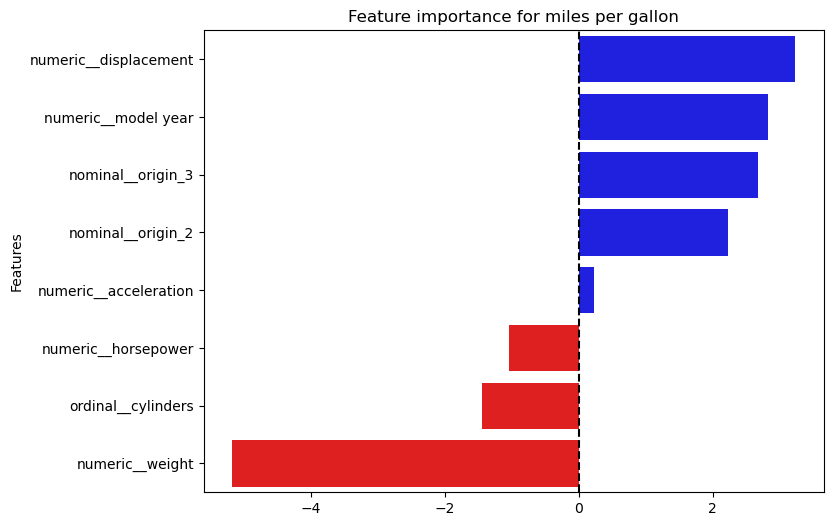

In [55]:
plt.figure( figsize = ( 8,6))
sns.barplot ( x=coef_ser.values,
              y = coef_ser.index , 
              hue = features , 
              palette = [ 'red' if x<0 else 'blue' for x in coef_ser.values],
              legend = False )
plt.title('Feature importance for miles per gallon' ) 
plt.ylabel ('Features' )
plt.axvline( 0 , color = 'k' , linestyle = 'dashed' )
plt.show()